<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/266228_01_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Práctica 01 Semana 11: Regresión Lineal Múltiple**

**Programación para analítica descriptiva y predictiva MIAAD**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*


###  **Objetivo de aprendizaje**
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

### **Datos**
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

**Parte 1: Carga de datos y bibliotecas**
- Importa las bibliotecas necesarias.
- Carga el archivo `advertising.csv`.
- Muestra las primeras filas del dataframe.
- Describe estadísticamente las variables.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# Carga de datos
df = pd.read_csv('/content/drive/MyDrive/ProgramacionMIAAD/advertising.csv')
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


**Observaciones:**

- El dataset contiene las variables TV, Radio y Newspaper, y la variable objetivo Sales
- No hay variables categóricas, todas son numéricas.

**Parte 2: Análisis exploratorio de los datos**

**2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes**
- Realiza gráficos de dispersión entre cada variable independiente (TV, Radio, Newspaper) y la variable dependiente (Sales). Usa también regplot.
- ¿Qué relación observas entre cada predictor y las ventas?

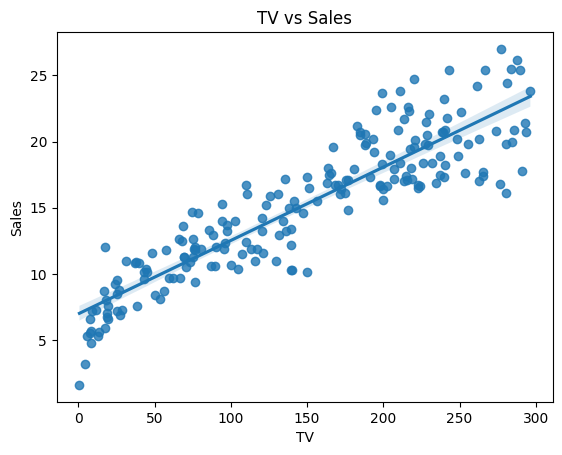

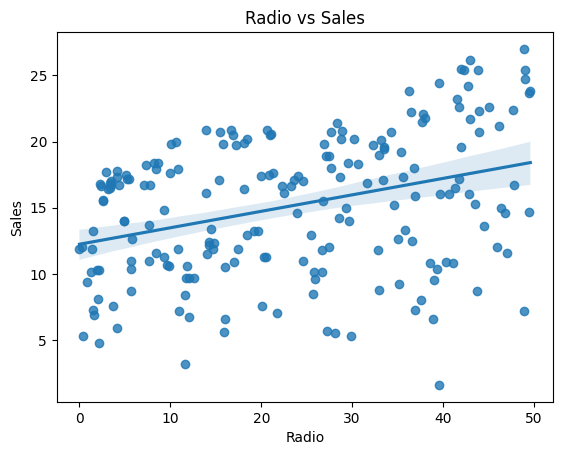

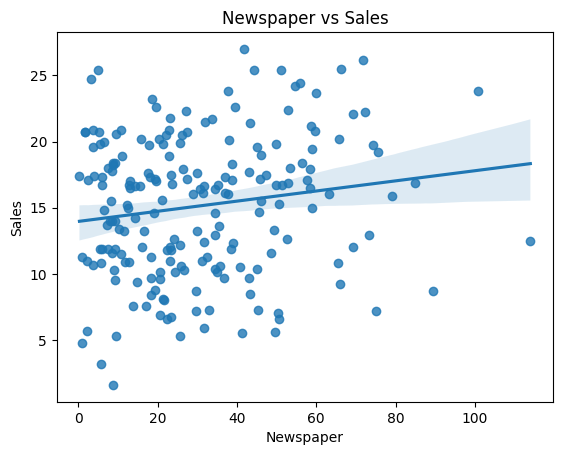

In [4]:
# Gráficos de dispersión (relación de las variables con Sales)
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['TV', 'Radio', 'Newspaper']

for var in variables:
    sns.regplot(x=df[var], y=df['Sales'])
    plt.title(f"{var} vs Sales")
    plt.show()

**Observaciones:**
- TV: fuerte relación lineal positiva
- Radio: relación positiva clara
- Newspaper: relación débil o casi nula

**2.2: Correlación entre variables**
- Calcula la matriz de correlación entre todas las variables
- Visualízala con un mapa de calor.
- Responde:
  - ¿Cuál variable tiene mayor correlación con Sales?
  - ¿Hay correlación alta entre predictores?

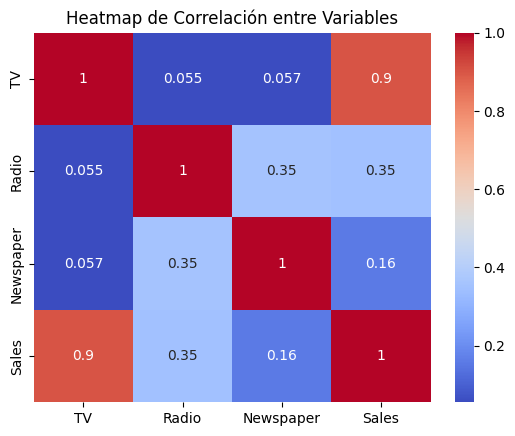

In [5]:
# Matriz de correlación y heatmap
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap de Correlación entre Variables")
plt.show()

**Observaciones:**
- TV tiene la mayor correlación con Sales
- La siguiente variable con mayor correlación es Radio
- Newspaper tiene baja correlación
- No hay alta correlación entre predictores, por lo tanto, existe baja multicolinealidad

**Parte 3. Multicolinealidad**
- Calcula el VIF (Variance Inflation Factor) para cada variable independiente.
- Crea un diagrama de barras  para mostrar el  VIF
- Interpreta los resultados:
  - ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
  - ¿Qué implicaciones tiene esto para el modelo?


### Análisis de Multicolinealidad ###
    Variable       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


/tmp/ipykernel_6174/232295344.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Variable', data=vif, palette='coolwarm')


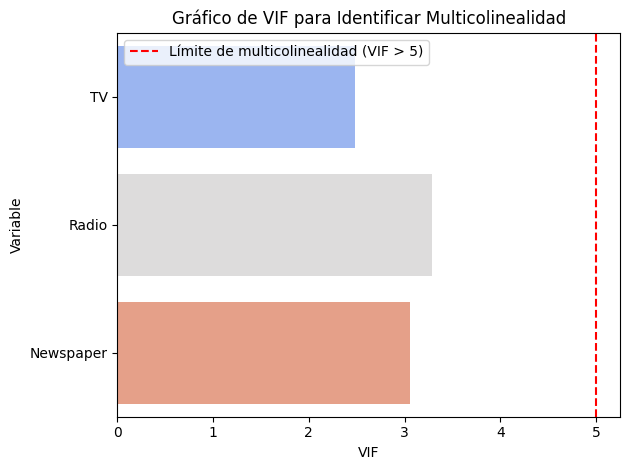

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

X = df[['TV', 'Radio', 'Newspaper']]

# Cálculo del VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n### Análisis de Multicolinealidad ###")
print(vif)

# Diagrama de barras del VIF
sns.barplot(x='VIF', y='Variable', data=vif, palette='coolwarm')
plt.axvline(x=5, color='red', linestyle='--', label='Límite de multicolinealidad (VIF > 5)')
plt.title("Gráfico de VIF para Identificar Multicolinealidad")
plt.legend()
plt.tight_layout()
plt.show()

**Observaciones:**
- Ninguna variable tiene un VIF mayor a 5
- En este dataset normalmente no hay multicolinealidad fuerte

**Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación**

**4.1 Entrenamiento del Modelo (Todas las Variables Independientes)**

- Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
- Imprime el intercepto y los coeficientes del modelo.
- Interpreta cada uno:
  - ¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Entrenamiento de modelo de regresión lineal múltiple
X = df[['TV', 'Radio', 'Newspaper']] # Variables independientes
y = df['Sales'] # Variable dependiente

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercepto:", model.intercept_)
print("Coeficientes:", list(zip(X.columns, model.coef_)))

Intercepto: 4.714126402214127
Coeficientes: [('TV', np.float64(0.05450927083721978)), ('Radio', np.float64(0.10094536239295579)), ('Newspaper', np.float64(0.0043366468220340446))]


**Observaciones:**
- La variable TV tiene un mayor impacto en ventas
- La variabke Radio tiene un impacto positivo importante
- La variable Newspaper tiene un impacto bajo

**4.2 Normalidad de los residuos**
- Calcula los residuos: residuos = y - y_pred.
- Grafica un histograma con KDE de los residuos.
- ¿Los residuos parecen distribuirse normalmente?

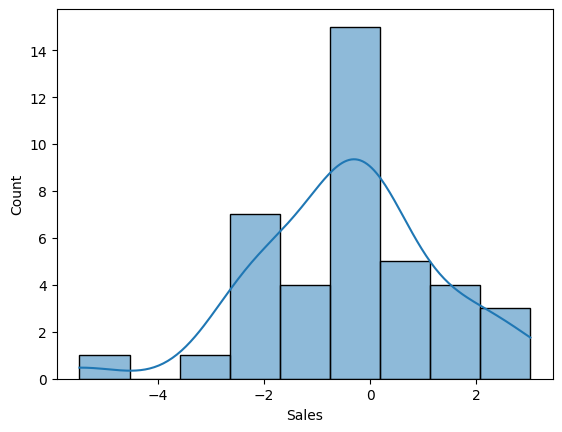

In [8]:
# Cálculo de los residuos
y_pred = model.predict(X_test)
resid = y_test - y_pred

# Histograma con KDE de los residuos
sns.histplot(resid, kde=True)
plt.show()

**Observaciones:**
- Los residuos se ven aproximadamente normales.

**4.3. Homocedasticidad**
- Grafica los residuos contra los valores predichos.
- ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

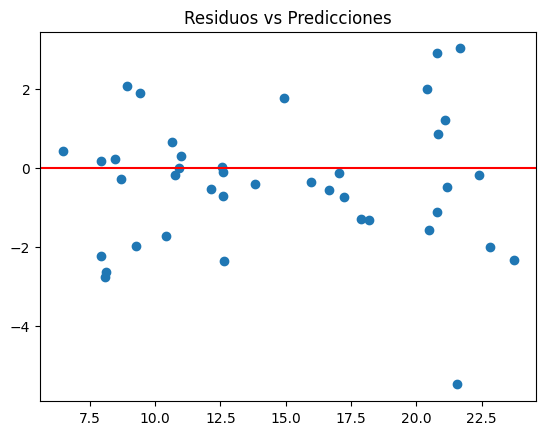

In [23]:
# Gráfica de residuos contra valores predichos
plt.scatter(y_pred, resid)
plt.axhline(0, color='red')
plt.title("Residuos vs Predicciones")
plt.show()

**Observaciones:**
- No se observa un patrón claro o sistemático. Los residuos no forman curvas ni estructuras definidas, lo cual es una buena señal.
- Los residuos se dispersan de forma relativamente aleatoria alrededor de cero, lo que sugiere que el modelo cumple razonablemente el supuesto de linealidad.

**4.4 Q-Q Plot**
- Graficar el Q-Q Plot
- Interpreta el gráfico:
  - Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.
  - Desviaciones sistemáticas indican asimetría o colas pesadas.

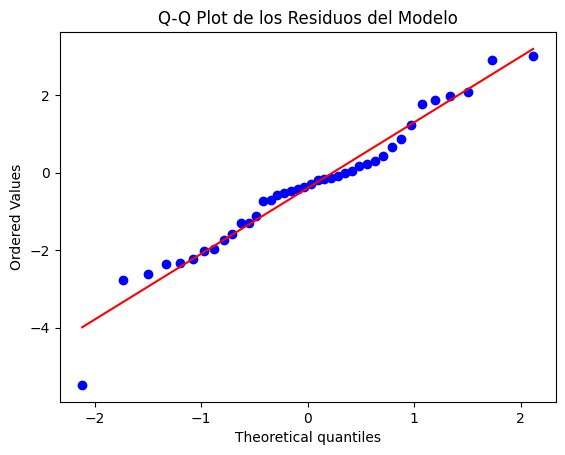

In [10]:
#Gráfico de Q-Q
import scipy.stats as stats

stats.probplot(resid, dist="norm", plot=plt)
plt.title("Q-Q Plot de los Residuos del Modelo")
plt.show()

**Interpretación:**
- Los puntos si siguen la línea diagonal, por lo cual siguen una distribución normal

**4.5. Evaluación del Modelo**
- Calcula las métricas:
  - MSE (error cuadrático medio)
  - RMSE (raíz del error cuadrático medio)
  - R² (coeficiente de determinación)
- ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [11]:
# Evaluación del Modelo
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Cálculo de métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

Error Cuadrático Medio (MSE): 2.9078
Raíz del Error Cuadrático Medio (RMSE): 1.7052
Coeficiente de Determinación (R²): 0.9059


**Interpretación:**
- El R² es alto (~0.9), por lo cual se considera un muy buen modelo
- Se tiene un error bajo, lo que significa un buen ajuste

**4.6. Visualización de Predicciones**
- Crea un gráfico comparando Sales reales vs Sales predichas.
- Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
- ¿Qué observas? ¿Qué información puedes obtener de esta gráfica?

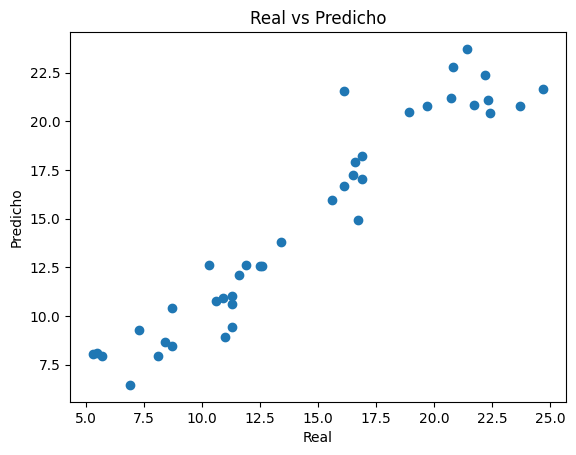

In [22]:
# Gráfico de Sales reales vs predichas
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.show()

**Observaciones:**
- Se observan que los puntos estarían cercanos a una diagonal, por lo tanto, esto indica un buen ajuste.

**4.7 Verificar el impacto de los atributos en el modelo**
- Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
- Interpreta los resultados:
  - Observa los valores P>|t| en la tabla de salida.
  - ¿Qué variables tienen p-value menores a 0.05?
  - ¿Cuál es la conclusión sobre esas variables?

In [13]:
# Cálculo de P-values
import statsmodels.api as sm

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        17:20:34   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

**Intepretación:**
- Las variables que tienen p-value menor a 0.05 son TV y Radio
- Estas variables son estadísticamente significativas, lo que implica que tienen un efecto real sobre la variable dependiente (Sales) y contribuyen al modelo.
- La variable Newspaper (p = 0.954) NO es significativa, ya que su p-value es mucho mayor a 0.05. Esto indica que:
  - No tiene un impacto estadísticamente relevante en las ventas
  - Su coeficiente podría ser prácticamente cero en términos prácticos
  - Puede eliminarse del modelo sin afectar significativamente el desempeño

**Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación**

**En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza lo siguiente.**

**5.1 Entrenamiento del Modelo**

- Entrena un modelo de regresión lineal múltiple sin usar las variables que presentaban multicolinealidad
- Imprime el intercepto y los coeficientes del modelo.
- Interpreta cada uno:
  - ¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [14]:
# Se elimina Newspaper porque no fue significativa (p > 0.05)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X2 = df[['TV', 'Radio']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

# Resultados
print("Intercepto:", model2.intercept_)
print("Coeficientes:", list(zip(X2.columns, model2.coef_)))

Intercepto: 4.791381661776025
Coeficientes: [('TV', np.float64(0.05450736175135675)), ('Radio', np.float64(0.10325763756778356))]


**Interpretación:**
- El modelo ahora incluye solo las variables significativas (TV y Radio)
- Los coeficientes indican cuánto aumentan las ventas por cada unidad adicional de inversión en cada medio.

**5.2 Normalidad de los residuos**
- Calcula los residuos: residuos = y - y_pred.
- Grafica un histograma con KDE de los residuos.
- ¿Los residuos parecen distribuirse normalmente?

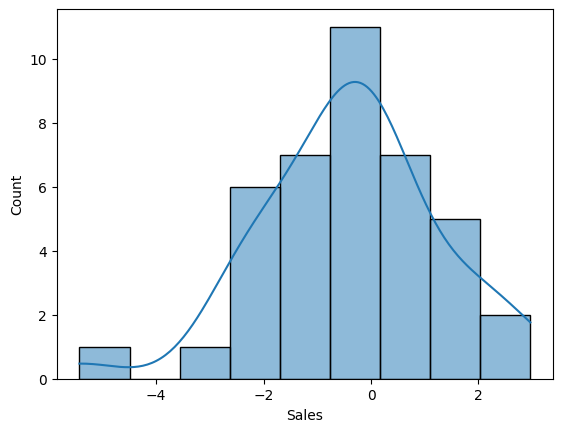

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cálculo de residuos
y_pred2 = model2.predict(X_test)
resid2 = y_test - y_pred2

# Histograma con KDE de los residuos
sns.histplot(resid2, kde=True)
plt.show()

**Interpretación:**

- Los residuos parecen distribuirse aproximadamente de manera normal, ya que presentan una forma cercana a una distribución simétrica tipo campana y están centrados alrededor de cero.

**5.3. Homocedasticidad**
- Grafica los residuos contra los valores predichos.
- ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

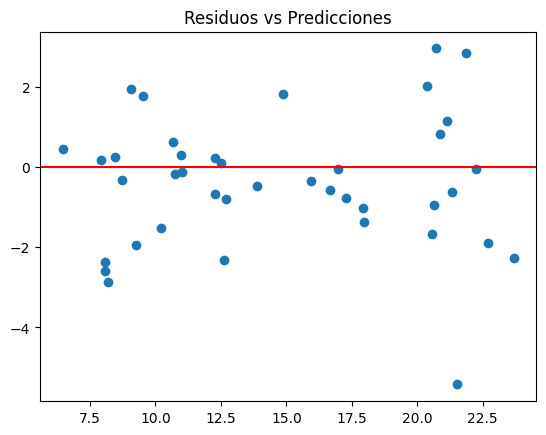

In [16]:
# Gráfico de los residuos vs valores predichos
plt.scatter(y_pred2, resid2)
plt.axhline(0, color='red')
plt.title("Residuos vs Predicciones")
plt.show()

**Observaciones:**
- No se observa un patrón claro o sistemático (como curvas o formas definidas). Los puntos no siguen una tendencia específica.
- Los residuos se dispersan de manera relativamente aleatoria alrededor de la línea horizontal en cero.

**5.4 Q-Q Plot**
- Graficar el Q-Q Plot
- Interpreta el gráfico:
  - Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.
  - Desviaciones sistemáticas indican asimetría o colas pesadas.

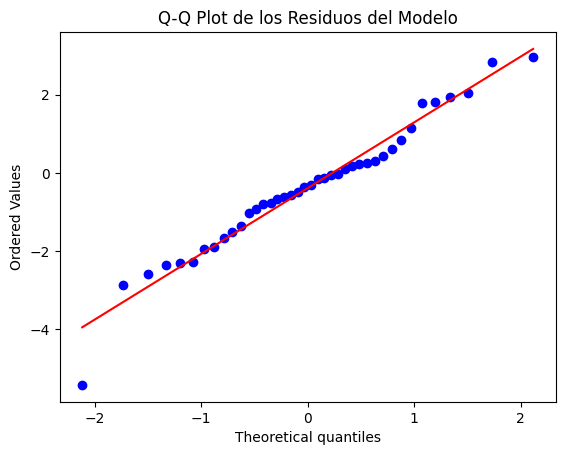

In [17]:
# Gráfica Q-Q Plot
import scipy.stats as stats

stats.probplot(resid2, dist="norm", plot=plt)
plt.title("Q-Q Plot de los Residuos del Modelo")
plt.show()

**Interpretación:**
- Los puntos se alinean en gran medida sobre la línea diagonal, lo que indica que los residuos siguen aproximadamente una distribución normal.

**5.5. Evaluación del Modelo**
- Calcula las métricas:
  - MSE (error cuadrático medio)
  - RMSE (raíz del error cuadrático medio)
  - R² (coeficiente de determinación)
- ¿Qué nos dicen estas métricas sobre el ajuste del modelo?

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Cálculo de MSE, RMSE y R2
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred2)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

Error Cuadrático Medio (MSE): 2.8466
Raíz del Error Cuadrático Medio (RMSE): 1.6872
Coeficiente de Determinación (R²): 0.9079


**Observaciones:**
- Las métricas indican que el modelo tiene un muy buen desempeño.
- El valor de R² cercano a 1 muestra que el modelo explica la mayor parte de la variabilidad en las ventas, mientras que los valores bajos de MSE y RMSE indican que los errores de predicción son pequeños.
- En conjunto, esto sugiere que el modelo tiene un ajuste adecuado y buena capacidad predictiva.

**5.6. Visualización de Predicciones**
- Crea un gráfico comparando Sales reales vs Sales predichas.
- Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.

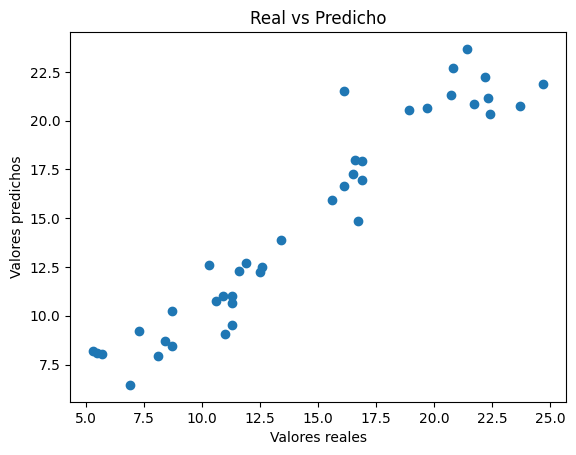

In [19]:
# Gráfico Sales reales vs predichas
plt.scatter(y_test, y_pred2)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Real vs Predicho")
plt.show()

**Intepretación:**
- Existe una buena concordancia entre los valores reales y los valores predichos.
- A medida que aumentan las ventas reales, también aumentan las predicciones del modelo, lo que indica que el modelo captura correctamente la relación entre las variables.

**5.7 Verificar el impacto de los atributos en el modelo**
- Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
- Interpreta los resultados:
  - Observa los valores P>|t| en la tabla de salida.
  - ¿Qué variables tienen p-value menores a 0.05?
  - ¿Cuál es la conclusión sobre esas variables?

In [20]:
X2_sm = sm.add_constant(X2)
model2_sm = sm.OLS(y, X2_sm).fit()

print(model2_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          2.39e-100
Time:                        17:20:36   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6309      0.290     15.952      0.0

**Interpretación:**
- Todas las variables del modelo (TV y Radio) tienen p-value < 0.05
- Ambas variables son estadísticamente significativas, lo que indica que:
  - Tienen un impacto real sobre las ventas (Sales)
  - Contribuyen significativamente al modelo
  - Sus coeficientes son confiables

**6. Conclusiones**
- ¿Cuál de los dos modelos construidos fue el mejor?
- ¿Cuál fue el atributo que mas influencia tiene en las ventas?


El análisis muestra que la inversión en TV es el factor más influyente en las ventas, seguida por la publicidad en radio. La variable Newspaper no presenta significancia estadística, por lo que su eliminación mejora la simplicidad del modelo sin afectar el desempeño. El modelo final presenta un buen ajuste (alto R²), cumpliendo razonablemente los supuestos de regresión lineal.